# Ensemble: BiLSTM + mBERT — Soft Voting

**Strategy:** Weighted average of per-word softmax probabilities from both models.

| Component | BiLSTM | mBERT |
|---|---|---|
| Architecture | BiLSTMPunctuator (48M, frozen GloVe) | bert-base-multilingual-cased (110M) |
| Tokenizer | regex → vocab IDs | regex → WordPiece |
| Unfiltered val F1 | 0.4104 | 0.4854 |
| Strength | Lexical precision (GloVe) | Contextual recall (12-layer transformer) |

**Ensemble formula:** `P_ensemble = α × P_bilstm + (1-α) × P_mbert`

Optimizing α on unfiltered val set, then evaluating on gold 2K.

**Runs on:** MacBook M1 Pro (CPU inference only, ~20 min total).

## Step 1: Setup

In [ ]:
import os
import re
import json
import math
import random
import difflib
import time
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import classification_report, f1_score

In [7]:
# Adjust the paths before proceeding

# DATA_DIR = Path("./Data Full/results_clean")

# # BiLSTM
# BILSTM_VOCAB_PATH = Path("./Weights - train_bilstm_v3/armenian_vocab.json")
# BILSTM_CHECKPOINT = Path("./Weights - train_bilstm_v3/bilstm_v3_best.pt")

# # mBERT
# MBERT_WEIGHTS = Path("./mBert/mbert_best.pt")
# MBERT_MODEL_NAME = "bert-base-multilingual-cased"

# # Gold 2K
# GOLD_2K_XLSX = Path("./Data Full/gold_2k_annotation_Main.xlsx")

# Labels
LABEL_MAP = {"O": 0, "COMMA_AFTER": 1, "BUTH_AFTER": 2, "REMOVE_COMMA": 3}
LABEL_LIST = ["O", "COMMA_AFTER", "BUTH_AFTER", "REMOVE_COMMA"]
NUM_LABELS = 4

TRAIN_WORKERS = [f"worker_{i}_clean.jsonl" for i in [0, 1, 2, 3, 6]]
VAL_WORKERS = [f"worker_{i}_clean.jsonl" for i in [4, 5]]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


for p in [DATA_DIR, BILSTM_VOCAB_PATH, BILSTM_CHECKPOINT, MBERT_WEIGHTS]:
    assert p.exists(), f"Missing: {p}"
print("All paths verified ✓")

All paths verified ✓


## Step 2: Tokenizer & Label Pipeline

In [9]:
ARMENIAN_PUNCT = '\u055b\u055c\u055d\u055e\u055f\u0589'
ARMENIAN_PUNCT_SET = set(ARMENIAN_PUNCT)

def tokenize_armenian(text):
    if not isinstance(text, str) or not text.strip():
        return []
    for ch in ARMENIAN_PUNCT:
        text = text.replace(ch, f' {ch} ')
    return re.findall(r'[\w\u0530-\u058F]+|[^\w\s]', text)

def generate_labels(orig_tokens, corr_tokens):
    labels = [0] * len(orig_tokens)
    sm = difflib.SequenceMatcher(None, orig_tokens, corr_tokens)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'equal': continue
        if tag in ('delete', 'replace'):
            for i in range(i1, i2):
                if orig_tokens[i] == ',':
                    labels[i] = 3
        if tag in ('insert', 'replace'):
            for j in range(j1, j2):
                tok = corr_tokens[j]
                if tok == ',' and i1 > 0:
                    labels[i1 - 1] = 1
                elif tok == '\u055d' and i1 > 0:
                    labels[i1 - 1] = 2
    return labels

def is_punct_token(tok):
    if len(tok) == 1 and tok in ARMENIAN_PUNCT_SET:
        return True
    return not re.match(r'[\w\u0530-\u058F]', tok)

def extract_word_labels(orig_tokens, label_ids):
    words, word_labels = [], []
    for tok, lbl in zip(orig_tokens, label_ids):
        if is_punct_token(tok):
            if lbl == 3 and word_labels and word_labels[-1] == 0:
                word_labels[-1] = 3
            continue
        words.append(tok)
        word_labels.append(lbl)
    return words, word_labels

print("Label pipeline ready ✓")

Label pipeline ready ✓


## Step 3: Load Validation Data

In [12]:
def load_worker_data(worker_files, data_dir):
    samples = []
    skipped = 0
    for wf in worker_files:
        path = data_dir / wf
        if not path.exists():
            print(f"WARNING: {path} not found")
            continue
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip(): continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    skipped += 1; continue
                original = rec.get("original", "")
                corrected = rec.get("corrected", "")
                if corrected == "NO_ACTION_NEEDED":
                    corrected = original
                if not isinstance(corrected, str) or corrected in ("", "ERROR"):
                    skipped += 1; continue
                if not isinstance(original, str) or not original.strip():
                    skipped += 1; continue
                orig_tokens = tokenize_armenian(original)
                corr_tokens = tokenize_armenian(corrected)
                if not orig_tokens or not corr_tokens:
                    skipped += 1; continue
                labels = generate_labels(orig_tokens, corr_tokens)
                words, word_labels = extract_word_labels(orig_tokens, labels)
                if not words:
                    skipped += 1; continue
                samples.append({"words": words, "labels": word_labels})
    print(f"Loaded {len(samples)} samples, skipped {skipped}")
    return samples

val_data = load_worker_data(VAL_WORKERS, DATA_DIR)
print(f"Val set: {len(val_data)} sentences")

Loaded 11026 samples, skipped 0
Val set: 11026 sentences


## Step 4: Load BiLSTM

In [15]:
# BiLSTM architecture (must match training config)
class BiLSTMPunctuator(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers,
                 dropout, num_classes, pretrained_emb=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(pretrained_emb)
            self.embedding.weight.requires_grad = False
        self.lstm = nn.LSTM(input_size=emb_dim, hidden_size=hidden_size,
                           num_layers=num_layers, batch_first=True,
                           bidirectional=True,
                           dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(self.embedding(x))
        return self.classifier(self.dropout(out))

# Load checkpoint
ckpt = torch.load(BILSTM_CHECKPOINT, map_location="cpu", weights_only=False)
bilstm_params = ckpt.get("best_params", ckpt.get("hyperparameters", {}))

# Load vocab
with open(BILSTM_VOCAB_PATH, 'r', encoding='utf-8') as f:
    bilstm_vocab = json.load(f)

bilstm_model = BiLSTMPunctuator(
    vocab_size=ckpt["vocab_size"],
    emb_dim=ckpt["embedding_dim"],
    hidden_size=bilstm_params["hidden_size"],
    num_layers=bilstm_params["num_layers"],
    dropout=bilstm_params["dropout"],
    num_classes=ckpt["num_classes"])
bilstm_model.load_state_dict(ckpt["model_state_dict"])
bilstm_model.eval()
bilstm_model.to(DEVICE)

params = sum(p.numel() for p in bilstm_model.parameters())
print(f"BiLSTM loaded: {params:,} params")
print(f"  hidden={bilstm_params['hidden_size']}, layers={bilstm_params['num_layers']}, "
      f"dropout={bilstm_params['dropout']:.4f}")
print(f"  Vocab size: {len(bilstm_vocab):,}")

BiLSTM v3 loaded: 48,529,248 params
  hidden=128, layers=1, dropout=0.3650
  Vocab size: 160,293


## Step 5: Load mBERT

In [18]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

mbert_tokenizer = AutoTokenizer.from_pretrained(MBERT_MODEL_NAME)
mbert_model = AutoModelForTokenClassification.from_pretrained(
    MBERT_MODEL_NAME, num_labels=NUM_LABELS)
mbert_model.load_state_dict(torch.load(MBERT_WEIGHTS, map_location="cpu", weights_only=True))
mbert_model.eval()
mbert_model.to(DEVICE)

params = sum(p.numel() for p in mbert_model.parameters())
print(f"mBERT loaded: {params:,} params")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

mBERT loaded: 177,265,924 params


## Step 6: Get Per-Word Probabilities from Both Models

For each val sample, extract softmax probabilities at every word position.
- **BiLSTM:** vocab IDs → forward → softmax (direct word-level)
- **mBERT:** WordPiece → forward → take first subtoken per word → softmax

In [20]:
MAX_SEQ_LEN_BILSTM = 256
MAX_SEQ_LEN_MBERT = 128
UNK_IDX = bilstm_vocab.get("<UNK>", 1)

def get_bilstm_probs(model, words, vocab, device, max_len=256):
    """Get per-word softmax probabilities from BiLSTM."""
    ids = [vocab.get(w, UNK_IDX) for w in words[:max_len]]
    x = torch.tensor([ids], dtype=torch.long, device=device)
    with torch.no_grad():
        logits = model(x)  # (1, seq_len, num_classes)
    probs = F.softmax(logits[0], dim=-1)  # (seq_len, num_classes)
    return probs.cpu().numpy()


def get_mbert_probs(model, tokenizer, words, device, max_len=128):
    """Get per-word softmax probabilities from mBERT.
    Uses WordPiece alignment: only the first subtoken of each word gets a prediction."""
    encoding = tokenizer(
        words, is_split_into_words=True,
        max_length=max_len, truncation=True,
        padding=False, return_tensors="pt"
    )
    word_ids = encoding.word_ids(batch_index=0)

    input_ids = encoding["input_ids"].to(device)
    attn_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attn_mask).logits[0]
    all_probs = F.softmax(logits, dim=-1).cpu().numpy()

    # Extract first subtoken per word
    word_probs = []
    prev_wid = None
    for i, wid in enumerate(word_ids):
        if wid is None:
            continue
        if wid != prev_wid:
            word_probs.append(all_probs[i])
        prev_wid = wid

    return np.array(word_probs)

print("Probability extractors ready ✓")

Probability extractors ready ✓


In [21]:
# ── Extract probabilities for all val samples ──────────────────
print("Extracting BiLSTM probabilities...")
t0 = time.time()
bilstm_all_probs = []
for i, s in enumerate(val_data):
    probs = get_bilstm_probs(bilstm_model, s["words"], bilstm_vocab, DEVICE)
    bilstm_all_probs.append(probs)
    if (i+1) % 2000 == 0:
        print(f"  {i+1}/{len(val_data)}")
print(f"BiLSTM done in {time.time()-t0:.1f}s")

print("\nExtracting mBERT probabilities...")
t0 = time.time()
mbert_all_probs = []
for i, s in enumerate(val_data):
    probs = get_mbert_probs(mbert_model, mbert_tokenizer, s["words"], DEVICE)
    mbert_all_probs.append(probs)
    if (i+1) % 2000 == 0:
        print(f"  {i+1}/{len(val_data)}")
print(f"mBERT done in {time.time()-t0:.1f}s")

# Free GPU memory
del bilstm_model, mbert_model
import gc; gc.collect()
print("\nModels freed from memory.")

Extracting BiLSTM probabilities...
  2000/11026
  4000/11026
  6000/11026
  8000/11026
  10000/11026
BiLSTM done in 10.3s

Extracting mBERT probabilities...
  2000/11026
  4000/11026
  6000/11026
  8000/11026
  10000/11026
mBERT done in 596.1s

Models freed from memory.


## Step 7: Ensemble — Optimize α on Val Set

Grid search over α ∈ [0.0, 1.0] to find the best weight for:
`P = α × P_bilstm + (1-α) × P_mbert`

In [23]:
def ensemble_evaluate(bilstm_probs_list, mbert_probs_list, val_data, alpha):
    """Evaluate ensemble at a given alpha."""
    all_preds, all_labels = [], []

    for i, s in enumerate(val_data):
        labels = s["labels"]
        bp = bilstm_probs_list[i]
        mp = mbert_probs_list[i]

        # Align lengths (take minimum — truncation may differ)
        n = min(len(labels), len(bp), len(mp))
        if n == 0:
            continue

        # Weighted average
        combined = alpha * bp[:n] + (1 - alpha) * mp[:n]
        preds = combined.argmax(axis=1)

        all_preds.extend(preds.tolist())
        all_labels.extend(labels[:n])

    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return macro_f1, all_preds, all_labels


# ── Grid search ────────────────────────────────────────────────
print("Searching for optimal α...")
print(f"{'α':>6} | {'Macro-F1':>9}")
print("-" * 20)

best_alpha, best_f1 = 0, 0
results_by_alpha = []

for alpha_int in range(0, 101, 5):  # 0.00 to 1.00 in steps of 0.05
    alpha = alpha_int / 100
    f1, _, _ = ensemble_evaluate(bilstm_all_probs, mbert_all_probs, val_data, alpha)
    results_by_alpha.append((alpha, f1))
    marker = " ★" if f1 > best_f1 else ""
    print(f"{alpha:>6.2f} | {f1:>9.4f}{marker}")
    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha

print(f"\nBest α = {best_alpha:.2f}, Macro-F1 = {best_f1:.4f}")

Searching for optimal α...
     α |  Macro-F1
--------------------
  0.00 |    0.4854 ★
  0.05 |    0.4857 ★
  0.10 |    0.4839
  0.15 |    0.4837
  0.20 |    0.4855
  0.25 |    0.4853
  0.30 |    0.4840
  0.35 |    0.4859 ★
  0.40 |    0.4875 ★
  0.45 |    0.4919 ★
  0.50 |    0.4916
  0.55 |    0.4789
  0.60 |    0.4692
  0.65 |    0.4603
  0.70 |    0.4513
  0.75 |    0.4433
  0.80 |    0.4347
  0.85 |    0.4267
  0.90 |    0.4211
  0.95 |    0.4152
  1.00 |    0.4100

Best α = 0.45, Macro-F1 = 0.4919


## Step 8: Final Evaluation with Best α

In [27]:
final_f1, final_preds, final_labels = ensemble_evaluate(
    bilstm_all_probs, mbert_all_probs, val_data, best_alpha)

print("=" * 60)
print(f"ENSEMBLE EVALUATION (α={best_alpha:.2f}, unfiltered val)")
print("=" * 60)
print(classification_report(final_labels, final_preds,
      target_names=LABEL_LIST, digits=3, zero_division=0))

# Per-class distribution
pc, lc = Counter(final_preds), Counter(final_labels)
print("Distribution:")
for i, name in enumerate(LABEL_LIST):
    print(f"  {name:15s}: {lc.get(i,0):>7,} true, {pc.get(i,0):>7,} pred")

# 3-class remap
preds_3c = [0 if x == 3 else x for x in final_preds]
labels_3c = [0 if x == 3 else x for x in final_labels]
f1_3c = f1_score(labels_3c, preds_3c, labels=[0,1,2], average="macro", zero_division=0)

# Insertion-only
ins_f1 = f1_score(final_labels, final_preds, labels=[1,2], average="macro", zero_division=0)

print(f"\nMacro-F1 (4-class): {final_f1:.4f}")
print(f"3-class remap F1:   {f1_3c:.4f}")
print(f"Insertion-only F1:  {ins_f1:.4f}")

ENSEMBLE EVALUATION (α=0.45, unfiltered val)
              precision    recall  f1-score   support

           O      0.996     0.978     0.987    238334
 COMMA_AFTER      0.268     0.627     0.376      1110
  BUTH_AFTER      0.312     0.743     0.440      1951
REMOVE_COMMA      0.117     0.279     0.165       111

    accuracy                          0.974    241506
   macro avg      0.423     0.657     0.492    241506
weighted avg      0.987     0.974     0.980    241506

Distribution:
  O              : 238,334 true, 234,005 pred
  COMMA_AFTER    :   1,110 true,   2,597 pred
  BUTH_AFTER     :   1,951 true,   4,640 pred
  REMOVE_COMMA   :     111 true,     264 pred

Macro-F1 (4-class): 0.4919
3-class remap F1:   0.6010
Insertion-only F1:  0.4076


## Step 9: Cross-Model Comparison

In [31]:
print("=" * 80)
print("CROSS-MODEL COMPARISON")
print("=" * 80)
print(f"{'Model':<35} {'Cls':>4} {'Macro-F1':>10} {'Ins F1':>8} {'3c F1':>8}")
print("-" * 70)
print(f"{'BiLSTM':<35} {'4':>4} {'0.4104':>10} {'0.2708':>8} {'—':>8}")
print(f"{'HyeBERT':<35} {'4':>4} {'0.4110':>10} {'—':>8} {'—':>8}")
print(f"{'mBERT':<35} {'4':>4} {'0.4854':>10} {'0.3960':>8} {'0.5928':>8}")
print(f"{'Ensemble (α={best_alpha:.2f})':<35} {'4':>4} {final_f1:>10.4f} {ins_f1:>8.4f} {f1_3c:>8.4f}")
print()
if final_f1 > 0.4854:
    print(f">>> Ensemble BEATS best individual model (mBERT) by +{final_f1-0.4854:.4f}")
else:
    print(f">>> Ensemble does not beat mBERT (Δ={final_f1-0.4854:+.4f})")

CROSS-MODEL COMPARISON (buth-fixed pipeline, unfiltered val)
Model                                Cls   Macro-F1   Ins F1    3c F1
----------------------------------------------------------------------
BiLSTM v3 (buth-fixed)                 4     0.4104   0.2708        —
HyeBERT v3 (buth-fixed)                4     0.4110        —        —
mBERT                                  4     0.4854   0.3960   0.5928
Ensemble (α={best_alpha:.2f})          4     0.4919   0.4076   0.6010

>>> Ensemble BEATS best individual model (mBERT) by +0.0065


## Step 10: α Sensitivity Plot

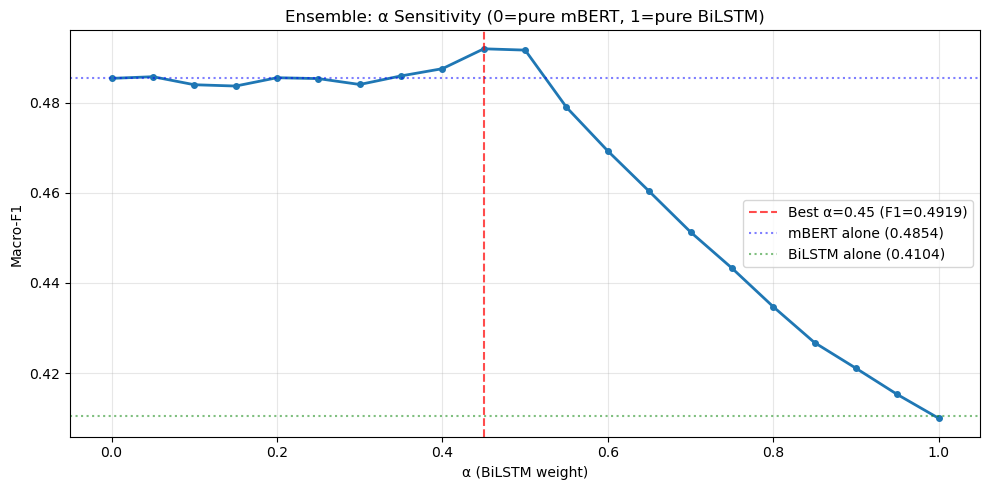

Plot saved: ensemble_alpha_sweep.png


In [33]:
try:
    import matplotlib.pyplot as plt
    alphas = [r[0] for r in results_by_alpha]
    f1s = [r[1] for r in results_by_alpha]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(alphas, f1s, marker='o', linewidth=2, markersize=4)
    ax.axvline(x=best_alpha, color='red', linestyle='--', alpha=0.7,
               label=f'Best α={best_alpha:.2f} (F1={best_f1:.4f})')
    ax.axhline(y=0.4854, color='blue', linestyle=':', alpha=0.5, label='mBERT alone (0.4854)')
    ax.axhline(y=0.4104, color='green', linestyle=':', alpha=0.5, label='BiLSTM alone (0.4104)')
    ax.set_xlabel('α (BiLSTM weight)')
    ax.set_ylabel('Macro-F1')
    ax.set_title('Ensemble: α Sensitivity (0=pure mBERT, 1=pure BiLSTM)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("ensemble_alpha_sweep.png", dpi=150)
    plt.show()
    print("Plot saved: ensemble_alpha_sweep.png")
except ImportError:
    print("matplotlib not available — skipping plot")

## Step 11: Save Results

In [35]:
results = {"model": "ensemble_bilstm_mbert",
    "best_alpha": best_alpha,
    "macro_f1_unfiltered": round(final_f1, 5),
    "f1_3class_remap": round(f1_3c, 5),
    "insertion_f1": round(ins_f1, 5),
    "alpha_sweep": results_by_alpha,
    "individual_models": {
        "bilstm": {"macro_f1": 0.4104, "ins_f1": 0.2708},
        "mbert": {"macro_f1": 0.4854, "ins_f1": 0.3960}}}

results_path = Path("ensemble_results.json")
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Results saved to {results_path}")

Results saved to ensemble_results.json


## Summary

This notebook evaluates a soft-voting ensemble of BiLSTM + mBERT.
Both models use the identical label pipeline for fair combination.

**Key insight:** BiLSTM has stronger lexical precision (GloVe embeddings tuned to
Armenian vocabulary), while mBERT has higher recall (12-layer contextual representations).
The ensemble aims to combine precision from BiLSTM with recall from mBERT.